In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Skip malformed rows instead of crashing the load
df = pd.read_csv('products_asos.csv', on_bad_lines='skip')
print(f"Data Loaded: {df.shape[0]} rows and {df.shape[1]} columns")


Data Loaded: 30845 rows and 9 columns


In [3]:
# Some prices are strings or empty — coerce forces them to NaN so we can drop cleanly
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

In [4]:
df['description'] = df['description'].astype(str)

In [5]:
# Brand is buried in description text like "Coats & Jackets by New Look..."
# We grab the first word after "by" as a raw token
def get_brand(text):
    if isinstance(text, str) and 'by' in text.lower():
        try:
            return text.split('by')[1].strip().split(' ')[0]
        except:
            return 'Unknown'
    return 'Unknown'


In [6]:
df['brand_raw'] = df['description'].apply(get_brand)

In [7]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [8]:
# Multi-word brands get truncated — fix the known ones manually
brand_map = {
    'New': 'New Look',
    'River': 'River Island',
    'Miss': 'Miss Selfridge',
    'TopshopWelcome': 'Topshop'
}
df['Brand'] = df['brand_raw'].replace(brand_map).fillna(df['brand_raw'])

In [9]:
# Drop brands with ≤5 products — too small to be statistically meaningful
brand_counts = df['brand_raw'].value_counts()
valid_brands = brand_counts[brand_counts > 5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()
print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS       4844
Topshop    1017
adidas      384
Vero        327
The         303
Name: count, dtype: int64


In [10]:
# function to analyze stock outs
def calculate_phantom_revenue(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0
    
    # split "UK 6, UK 8 and out of stock" into list
    sizes = size_str.split(',')
    total_sizes = len(sizes)
    
    # count how many items are out of stock
    out_of_stock_count = size_str.count('Out of stock')
    
    # calculate Rate (0.0 to 1.0)
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0
    
    return out_of_stock_count, rate

In [11]:
metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))
df_clean['Stock_Count'] = [x[0] for x in metrics]
df_clean['Stock_Rate'] = [x[1] for x in metrics]

In [12]:
# Proxy for lost revenue: price × number of OOS size slots
df_clean['Lost_Revenue'] = df_clean['price'] * df_clean['Stock_Count']

In [13]:
cols = ['Brand', 'name', 'price', 'Stock_Count', 'Stock_Rate', 'Lost_Revenue']
print(df_clean.sort_values(by = 'Lost_Revenue', ascending=False).head(5)[cols])

         Brand                                               name  price  \
2941   Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshop  Topshop premium real leather collared zip thro...  260.0   
2715      ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584     ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stock_Count  Stock_Rate  Lost_Revenue  
2941             9    0.900000        1971.0  
21948            7    0.875000        1820.0  
2715             7    0.875000        1540.0  
15584            6    0.750000        1500.0  
29838           27    0.931034        1350.0  


In [14]:
# Aggregate to brand level — only keep brands with enough products for signal
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stock_Rate': 'mean',
    'Stock_Count': 'sum',
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_strategy = brand_strategy[brand_strategy['name'] > 10]

C:\Users\adham\AppData\Local\Temp\ipykernel_1016\919496417.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


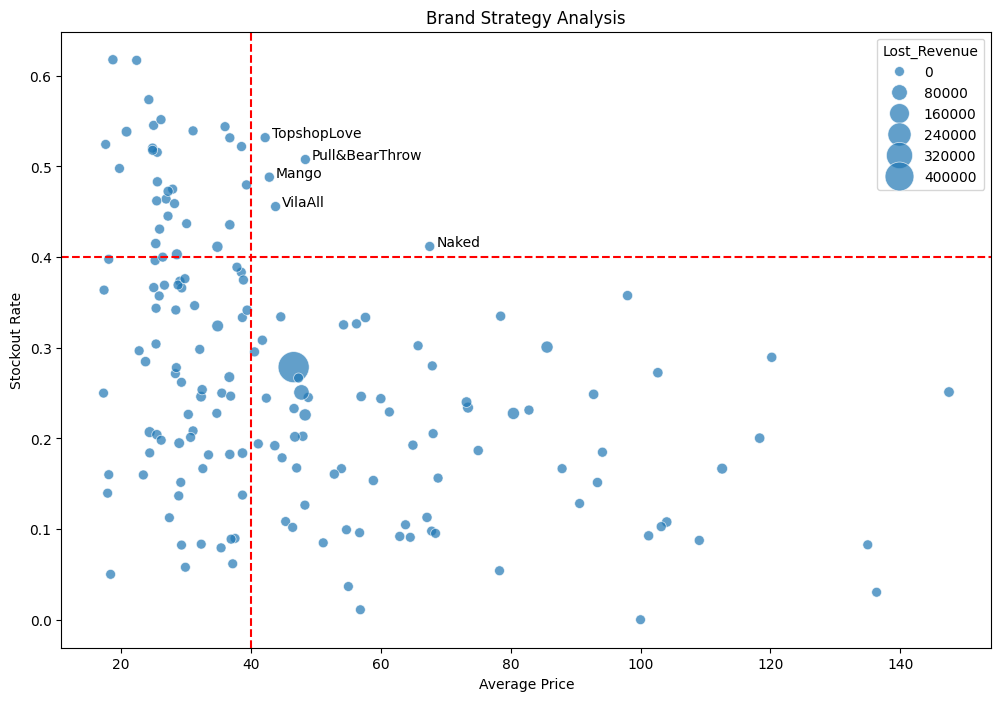

In [15]:
# Plot: x=price positioning, y=stockout severity, bubble=revenue at risk

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy, 
    x='price', 
    y='Stock_Rate', 
    size='Lost_Revenue', 
    sizes=(50, 500), 
    alpha=0.7,
    palette='viridis'
)


# Label only the high-risk quadrant (premium price + high stockout)
winners = brand_strategy[
    (brand_strategy['price'] > 40)
    & (brand_strategy['Stock_Rate'] > 0.4)
]

for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1, 
        winners.iloc[i]['Stock_Rate'], 
        winners.iloc[i]['Brand'],
    )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')   # price threshold
plt.axhline(y=0.4, color='red', linestyle='--')  # stockout threshold
plt.show()